# FortyGuard Hackathon — Temperature vs. Electricity Demand Regression Toolkit

**Track 7: Data Analysis & Correlation** — Colab version

**Setup (run the first cell, then follow the prompts):**
1. It clones the official quickstart repo and installs dependencies.
2. It asks you to paste your `FORTYGUARD_API_KEY` and `EIA_API_KEY` (get the EIA one free at https://www.eia.gov/opendata/register.php).

**Pipeline:**
1. Build a small AOI (bounding box) around a chosen U.S. city
2. Loop over days, calling `create_heatmap(filter_type=3)` to get that day's average temperature
3. Pull matching daily electricity demand from EIA
4. Merge, regress, plot
5. Generalize into a reusable toolkit function for any user-supplied outcome CSV


In [1]:
# --- Colab setup: clone the client repo and install dependencies ---
!git clone --depth 1 https://github.com/FortyGuard-Tech/temperature-api-quickstart.git
%cd temperature-api-quickstart
!pip install -r requirements.txt -q


Cloning into 'temperature-api-quickstart'...
remote: Enumerating objects: 66, done.
remote: Counting objects: 100% (66/66), done.
remote: Compressing objects: 100% (58/58), done.
remote: Total 66 (delta 8), reused 55 (delta 8), pack-reused 0 (from 0)
Receiving objects: 100% (66/66), 14.88 MiB | 13.16 MiB/s, done.
Resolving deltas: 100% (8/8), done.
/content/temperature-api-quickstart
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 38.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.1/140.1 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 53.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 915.3/915.3 kB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 217.3/217.3 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 55.5 

In [2]:
import sys, pathlib, time, os
sys.path.insert(0, str(pathlib.Path.cwd()))  # so `import fortyguard` works

import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

from fortyguard import FortyGuardClient
from getpass import getpass

# Paste your keys when prompted (kept only in this session's memory, not saved to disk)
os.environ["FORTYGUARD_API_KEY"] = getpass("FortyGuard API key: ")
EIA_API_KEY = getpass("EIA API key: ")

client = FortyGuardClient()  # picks up FORTYGUARD_API_KEY from the env var just set


FortyGuard API key: ··········
EIA API key: ··········


In [3]:
# --- Config ---
CITY_NAME = "Phoenix, AZ"
CENTER_LAT = 33.4484
CENTER_LON = -112.0740
EIA_RESPONDENT = "AZPS"  # balancing authority code — verify on EIA's site for your chosen city

# Keep the study window modest at first (each day = one API call + poll).
# Widen later once you've confirmed the pipeline works end-to-end.
START_DATE = "2026-06-01"
END_DATE = "2026-07-31"   # ~60 days -> ~60 API calls

GRANULARITY = 100  # coarsest/cheapest — fine since we only need the AOI-wide average, not spatial detail
AOI_HALF_SIZE_KM = 1.0  # ~2km x 2km box around the center point


In [4]:
def make_point_aoi(lat, lon, half_size_km=1.0):
    """Small square polygon AOI (GeoJSON) centered on a point. Coordinates are [lon, lat]."""
    km_per_deg_lat = 111.0
    km_per_deg_lon = 111.0 * np.cos(np.radians(lat))
    d_lat = half_size_km / km_per_deg_lat
    d_lon = half_size_km / km_per_deg_lon
    ring = [
        [lon - d_lon, lat - d_lat],
        [lon + d_lon, lat - d_lat],
        [lon + d_lon, lat + d_lat],
        [lon - d_lon, lat + d_lat],
        [lon - d_lon, lat - d_lat],
    ]
    return {
        "type": "FeatureCollection",
        "features": [{
            "type": "Feature", "properties": {},
            "geometry": {"type": "Polygon", "coordinates": [ring]},
        }],
    }

AOI = make_point_aoi(CENTER_LAT, CENTER_LON, AOI_HALF_SIZE_KM)


In [5]:
def get_daily_temperature(client, aoi, date_str, granularity=100, verbose=False):
    """Single day (filter_type=3) -> AOI-wide average/min/max temperature in °C."""
    response = client.create_heatmap(
        polygon_aoi=aoi,
        start_date=date_str,
        filter_type=3,
        granularity=granularity,
        verbose=verbose,
    )
    stats = response["result"].get("stats_data", {})
    temp_stats = stats.get("temperature_stats", {})
    return {
        "date": date_str,
        "avg_temp_c": temp_stats.get("mean"),
        "min_temp_c": temp_stats.get("minimum"),
        "max_temp_c": temp_stats.get("maximum"),
    }


In [6]:
response = client.create_heatmap(
    polygon_aoi=AOI,
    start_date=START_DATE,
    filter_type=3,
    granularity=GRANULARITY,
    verbose=True,
)
stats = response["result"].get("stats_data", {})
print(stats)

Submitted -> activity_id=2e9dbff3-3f33-4446-b2e0-920d17fb0049
  status: processing
  status: processing
  status: processing
  status: processing
  status: processing
  status: processing
  status: completed
Done.
{'temperature_stats': {'minimum': 31.5268, 'maximum': 32.1048, 'mean': 31.936489260143198, 'standard_deviation': 0.12711938687998445}, 'overall_temperature_distribution': [31.5268, 31.920250000000003, 31.967, 32.02405, 32.1048], 'normal_temperature_distribution': {'x_axis': [31.555131099503246, 31.5628353047687, 31.570539510034152, 31.578243715299607, 31.58594792056506, 31.593652125830513, 31.601356331095968, 31.609060536361422, 31.616764741626874, 31.62446894689233, 31.632173152157783, 31.639877357423234, 31.64758156268869, 31.655285767954144, 31.662989973219595, 31.67069417848505, 31.678398383750505, 31.686102589015956, 31.69380679428141, 31.701510999546866, 31.709215204812317, 31.71691941007777, 31.724623615343226, 31.732327820608678, 31.740032025874132, 31.747736231139587

In [ ]:
# --- Build the daily temperature series (loops one API call per day) ---
# Saves incrementally to CSV so a crash/interrupt (or Colab disconnect) doesn't
# lose progress — re-run this cell and it will skip days already fetched.
# NOTE: Colab's filesystem is ephemeral — if your runtime resets, this cache
# resets too. Download data/temp_series_cache.csv periodically if the run is long.

CACHE_PATH = pathlib.Path("data/temp_series_cache.csv")
CACHE_PATH.parent.mkdir(parents=True, exist_ok=True)

if CACHE_PATH.exists():
    temp_df = pd.read_csv(CACHE_PATH, parse_dates=["date"])
else:
    temp_df = pd.DataFrame(columns=["date", "avg_temp_c", "min_temp_c", "max_temp_c"])

fetched_dates = set(temp_df["date"].dt.strftime("%Y-%m-%d")) if not temp_df.empty else set()
date_range = pd.date_range(START_DATE, END_DATE, freq="D")

rows = temp_df.to_dict("records")
for d in date_range:
    date_str = d.strftime("%Y-%m-%d")
    if date_str in fetched_dates:
        continue
    try:
        row = get_daily_temperature(client, AOI, date_str, granularity=GRANULARITY)
        rows.append(row)
        print(f"{date_str}: avg {row['avg_temp_c']} C")
    except Exception as e:
        print(f"{date_str}: FAILED — {e}")
    time.sleep(0.5)  # be polite to the API between calls
    pd.DataFrame(rows).to_csv(CACHE_PATH, index=False)

temp_df = pd.DataFrame(rows)
temp_df["date"] = pd.to_datetime(temp_df["date"])
temp_df = temp_df.sort_values("date").reset_index(drop=True)
temp_df.head()


2026-06-01: avg 31.936489260143198 C
2026-06-02: avg 33.80657780429594 C
2026-06-03: avg 33.392585918854415 C
2026-06-04: avg 34.5912291169451 C
2026-06-05: avg 35.15126539379475 C
2026-06-06: avg 33.96345966587111 C
2026-06-07: avg 34.026710978520285 C
2026-06-08: avg 33.223336038186154 C
2026-06-09: avg 32.84571408114559 C
2026-06-10: avg 33.5506446300716 C
2026-06-11: avg 35.175621718377094 C
2026-06-12: avg 36.53844653937947 C
2026-06-13: avg 37.1668737470167 C
2026-06-14: avg 37.49951813842482 C
2026-06-15: avg 37.13945011933174 C
2026-06-16: avg 37.8251830548926 C
2026-06-17: avg 37.61536730310262 C
2026-06-18: avg 35.933306205250595 C
2026-06-19: avg 35.22102792362769 C
2026-06-20: avg 34.30141646778043 C
2026-06-21: avg 33.771057995226734 C
2026-06-22: avg 35.04232696897375 C
2026-06-23: avg 37.33669093078759 C
2026-06-24: avg 37.70978257756563 C
2026-06-25: avg 37.931467541766104 C
2026-06-26: avg 37.69388735083532 C
2026-06-27: avg 35.848264916467784 C
2026-06-28: avg 34.2674

In [20]:
def fetch_eia_daily_demand(start_date, end_date, respondent, api_key):
    """Hourly demand from EIA's Electricity RTO API, aggregated to daily mean."""
    url = "https://api.eia.gov/v2/electricity/rto/region-data/data/"
    params = {
        "api_key": api_key,
        "frequency": "hourly",
        "data[0]": "value",
        "facets[respondent][]": respondent,
        "facets[type][]": "D",  # D = Demand
        "start": start_date,
        "end": end_date,
        "sort[0][column]": "period",
        "sort[0][direction]": "asc",
        "length": 5000,
    }
    resp = requests.get(url, params=params)
    resp.raise_for_status()
    records = resp.json()["response"]["data"]
    df = pd.DataFrame(records)
    df["timestamp"] = pd.to_datetime(df["period"])
    df["demand_mwh"] = pd.to_numeric(df["value"])
    daily = df.set_index("timestamp")["demand_mwh"].resample("D").mean().reset_index()
    daily = daily.rename(columns={"timestamp": "date"})
    return daily

demand_df = fetch_eia_daily_demand(START_DATE, END_DATE, EIA_RESPONDENT, EIA_API_KEY)
demand_df.head()


,date,demand_mwh
0,2026-06-01,4684.125000
1,2026-06-02,5142.750000
2,2026-06-03,5165.041667
3,2026-06-04,5809.583333
4,2026-06-05,5860.250000


In [15]:
merged_df = pd.merge(temp_df, demand_df, on="date", how="inner").dropna(subset=["avg_temp_c", "demand_mwh"])
print(f"{len(merged_df)} matched days")
merged_df.head()


61 matched days


,date,avg_temp_c,min_temp_c,max_temp_c,demand_mwh
0,2026-06-01,31.936489,31.5268,32.1048,4684.125000
1,2026-06-02,33.806578,33.7031,33.8477,5142.750000
2,2026-06-03,33.392586,33.2798,33.5409,5165.041667
3,2026-06-04,34.591229,34.4352,34.7823,5809.583333
4,2026-06-05,35.151265,35.1100,35.2163,5860.250000


## Regression

Simple OLS first, then a cooling-degree-day feature (AC load tends to respond non-linearly above a comfort threshold).


In [16]:
def run_linear_regression(df, x_col="avg_temp_c", y_col="demand_mwh"):
    X = sm.add_constant(df[x_col])
    y = df[y_col]
    return sm.OLS(y, X).fit()

def add_cooling_degree_feature(df, threshold_c=26.0, temp_col="avg_temp_c"):
    df = df.copy()
    df["cooling_degrees"] = (df[temp_col] - threshold_c).clip(lower=0)
    return df

def run_degree_day_regression(df, y_col="demand_mwh", threshold_c=26.0):
    df = add_cooling_degree_feature(df, threshold_c=threshold_c)
    X = sm.add_constant(df["cooling_degrees"])
    y = df[y_col]
    return sm.OLS(y, X).fit()

linear_model = run_linear_regression(merged_df)
print(linear_model.summary())


                            OLS Regression Results                            
Dep. Variable:             demand_mwh   R-squared:                       0.697
Model:                            OLS   Adj. R-squared:                  0.692
Method:                 Least Squares   F-statistic:                     135.9
Date:                Thu, 27 Aug 2026   Prob (F-statistic):           5.99e-17
Time:                        02:00:58   Log-Likelihood:                -452.55
No. Observations:                  61   AIC:                             909.1
Df Residuals:                      59   BIC:                             913.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -4058.1663    861.677     -4.710      0.0

In [17]:
degree_day_model = run_degree_day_regression(merged_df)
print(degree_day_model.summary())


                            OLS Regression Results                            
Dep. Variable:             demand_mwh   R-squared:                       0.697
Model:                            OLS   Adj. R-squared:                  0.692
Method:                 Least Squares   F-statistic:                     135.9
Date:                Thu, 27 Aug 2026   Prob (F-statistic):           5.99e-17
Time:                        02:01:03   Log-Likelihood:                -452.55
No. Observations:                  61   AIC:                             909.1
Df Residuals:                      59   BIC:                             913.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const            3212.2619    242.273     

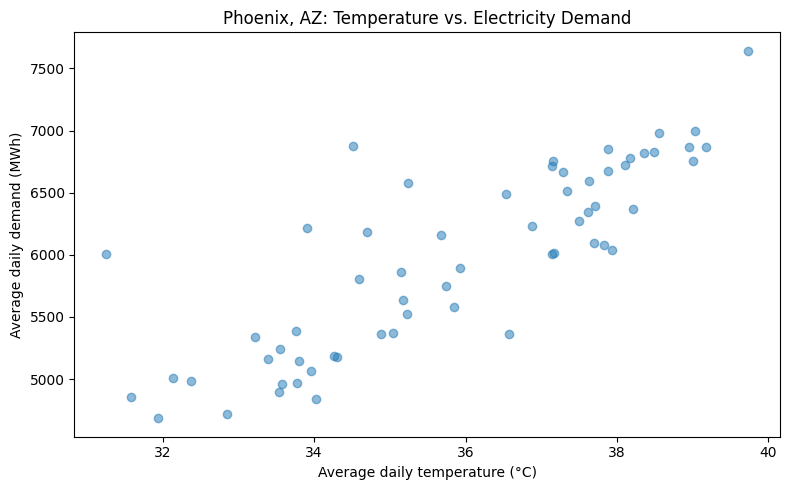

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(merged_df["avg_temp_c"], merged_df["demand_mwh"], alpha=0.5)
ax.set_xlabel("Average daily temperature (°C)")
ax.set_ylabel("Average daily demand (MWh)")
ax.set_title(f"{CITY_NAME}: Temperature vs. Electricity Demand")
plt.tight_layout()
plt.show()


## Toolkit function (generalized)

Takes a user CSV of `[date, lat, lon, outcome_value]`, builds an AOI per unique `(lat, lon)`, fetches matching daily temperature, merges, and regresses. This is the reusable "regression toolkit" piece — the demand example above is just one instantiation.


In [21]:
def regression_toolkit(client, user_csv_path, outcome_col="outcome_value", aoi_half_size_km=1.0, granularity=100):
    """
    user_csv columns required: date (YYYY-MM-DD), lat, lon, outcome_col
    Batches API calls by unique (lat, lon) pair rather than per-row, since many
    rows typically share the same site.
    """
    user_df = pd.read_csv(user_csv_path, parse_dates=["date"])
    user_df["date_str"] = user_df["date"].dt.strftime("%Y-%m-%d")

    results = []
    for (lat, lon), group in user_df.groupby(["lat", "lon"]):
        aoi = make_point_aoi(lat, lon, aoi_half_size_km)
        for date_str in group["date_str"].unique():
            temp_row = get_daily_temperature(client, aoi, date_str, granularity=granularity)
            temp_row.update({"lat": lat, "lon": lon})
            results.append(temp_row)
            time.sleep(0.5)

    temp_lookup = pd.DataFrame(results)
    merged = pd.merge(
        user_df, temp_lookup,
        left_on=["lat", "lon", "date_str"], right_on=["lat", "lon", "date"],
        how="inner",
    )
    model = run_linear_regression(merged, x_col="avg_temp_c", y_col=outcome_col)
    return model, merged

# model, merged = regression_toolkit(client, "data/my_outcomes.csv", outcome_col="outcome_value")
# print(model.summary())
